#  Heart Disease UCI Dataset - Exploratory Data Analysis (EDA)

**Author:** Pronab Sardar  
**Dataset:** UCI Heart Disease (Cleveland)

## 🎯 Objectives
1. Understand dataset structure and quality
2. Analyze missing values and data types
3. Explore target class distribution
4. Visualize numerical feature distributions
5. Analyze categorical feature relationships with target
6. Compute correlation between features
7. Identify outliers via box plots
8. Generate interactive visualizations with Plotly
9. Derive actionable insights for feature engineering

## 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Color palette (green for no disease, red for disease)
PALETTE = ['#2ecc71', '#e74c3c']

# Ensure screenshots folder exists
os.makedirs('../screenshots/mlflow', exist_ok=True)

print('✅ All libraries loaded successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

✅ All libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.3.5


## 2. Load the Dataset

In [2]:
# Load the Heart Disease UCI dataset
df = pd.read_csv('../data/raw/heart_disease.csv')

print(f'📊 Dataset Shape: {df.shape}')
print(f'📊 Total Rows: {df.shape[0]:,}')
print(f'📊 Total Columns: {df.shape[1]}')
print(f'\n📋 Column Names: {df.columns.tolist()}')

📊 Dataset Shape: (303, 14)
📊 Total Rows: 303
📊 Total Columns: 14

📋 Column Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [3]:
# Preview the first 5 rows
print('First 5 rows:')
df.head()

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Preview the last 5 rows
print('Last 5 rows:')
df.tail()

Last 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


### 📖 Feature Dictionary

| Feature | Description | Type |
|---------|-------------|------|
| **age** | Age in years | Numeric |
| **sex** | 1=Male, 0=Female | Categorical |
| **cp** | Chest pain type (0-3) | Categorical |
| **trestbps** | Resting blood pressure (mm Hg) | Numeric |
| **chol** | Serum cholesterol (mg/dl) | Numeric |
| **fbs** | Fasting blood sugar > 120 mg/dl (1/0) | Binary |
| **restecg** | Resting ECG results (0-2) | Categorical |
| **thalach** | Maximum heart rate achieved | Numeric |
| **exang** | Exercise-induced angina (1/0) | Binary |
| **oldpeak** | ST depression induced by exercise | Numeric |
| **slope** | Slope of peak exercise ST segment | Categorical |
| **ca** | Number of major vessels colored (0-3) | Numeric |
| **thal** | Thalassemia type | Categorical |
| **target** | Heart disease (1=Yes, 0=No) | Binary |

## 3. Data Types & Statistical Summary

In [5]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Memory Usage ===')
print(f'{df.memory_usage(deep=True).sum() / 1024:.2f} KB')

=== Data Types ===
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

=== Memory Usage ===
33.27 KB


In [6]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe().T.round(2)

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


In [7]:
# Info() for compact overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 4. Missing Value Analysis

In [8]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if not missing_df.empty:
    print('❗ Columns with Missing Values:')
    print(missing_df)
else:
    print('✅ No missing values in the dataset!')

❗ Columns with Missing Values:
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66


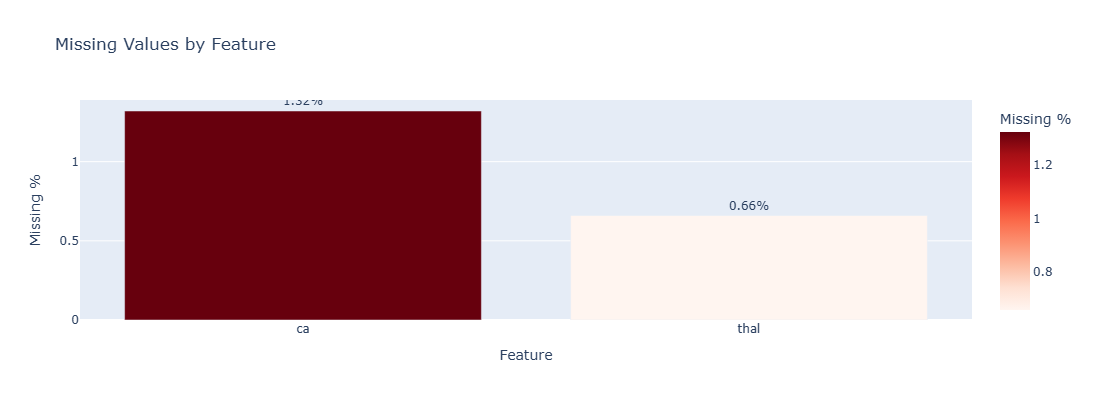

In [9]:
# Interactive Plotly visualization for missing values
if not missing_df.empty:
    fig = px.bar(
        missing_df, x=missing_df.index, y='Missing %',
        title='Missing Values by Feature',
        color='Missing %',
        color_continuous_scale='Reds',
        text='Missing %'
    )
    fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
    fig.update_layout(height=400, xaxis_title='Feature', yaxis_title='Missing %')
    fig.show()
else:
    print('No missing values to visualize.')

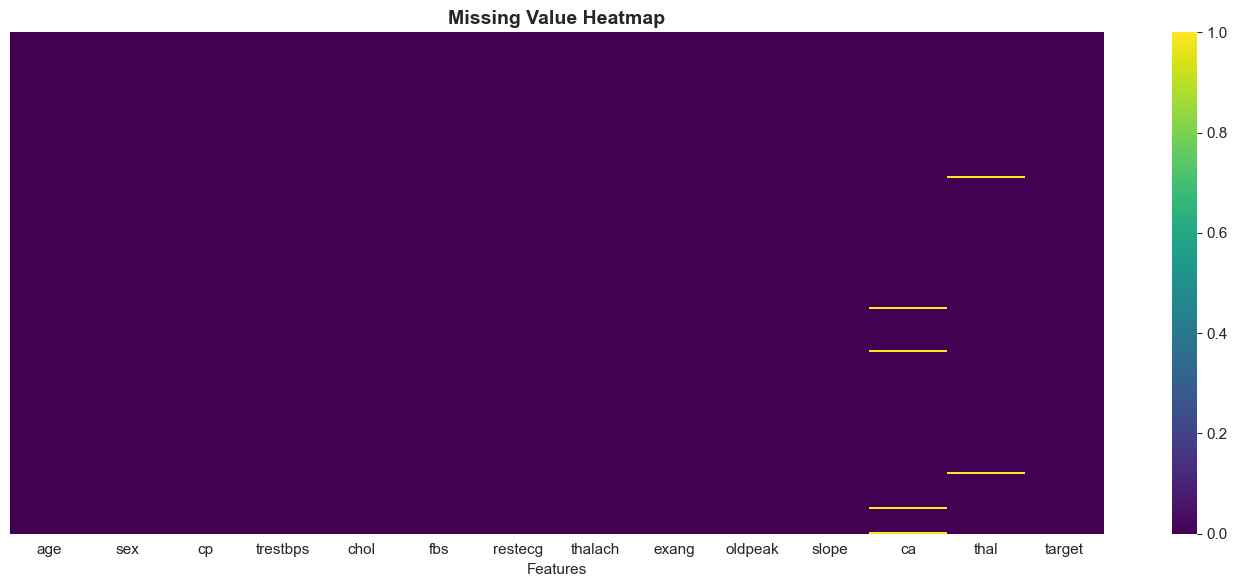

In [10]:
# Missing value heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.tight_layout()
plt.savefig('../screenshots/mlflow/missing_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Target Variable Analysis (Class Distribution)

In [11]:
# Class distribution counts and percentages
print('🎯 Target Class Distribution:')
print(df['target'].value_counts())
print(f'\n📊 Percentage:')
print((df['target'].value_counts(normalize=True) * 100).round(2))
print(f'\n⚖️ Balance Ratio: {df["target"].value_counts()[0] / df["target"].value_counts()[1]:.2f}:1')

🎯 Target Class Distribution:
target
0    164
1    139
Name: count, dtype: int64

📊 Percentage:
target
0    54.13
1    45.87
Name: proportion, dtype: float64

⚖️ Balance Ratio: 1.18:1


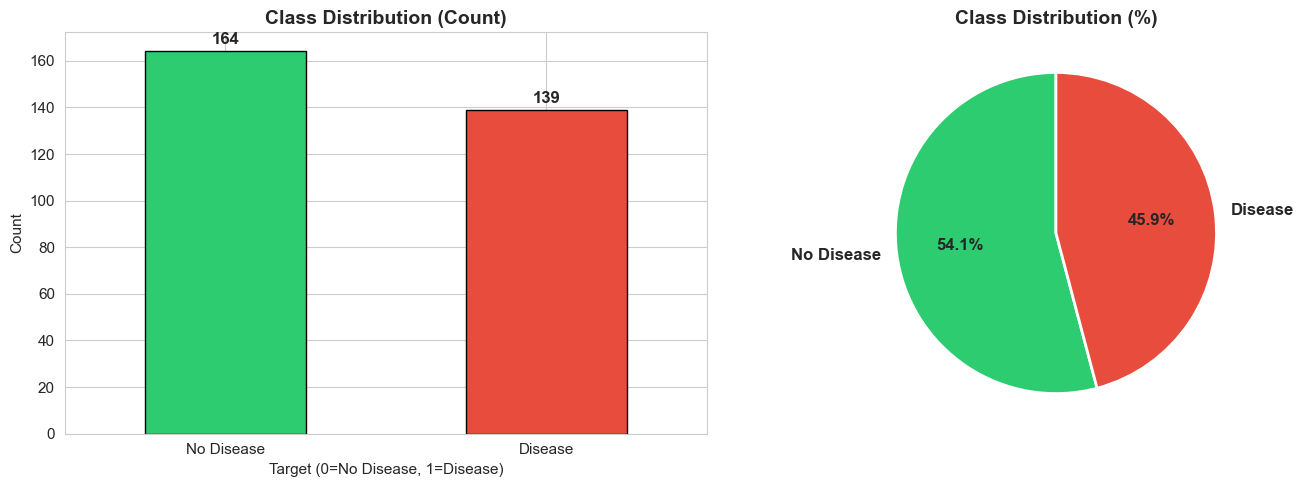


✅ Dataset is well-balanced - no oversampling required.


In [12]:
# Class distribution: Bar + Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['target'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
counts.plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=PALETTE, startangle=90,
    labels=['No Disease', 'Disease'],
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../screenshots/mlflow/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n✅ Dataset is well-balanced - no oversampling required.')

## 6. Numerical Feature Analysis

In [13]:
# Define numerical features
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print(f'📊 Numerical features: {num_features}')
print('\nStatistical summary of numerical features:')
df[num_features].describe().T.round(2)

📊 Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Statistical summary of numerical features:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


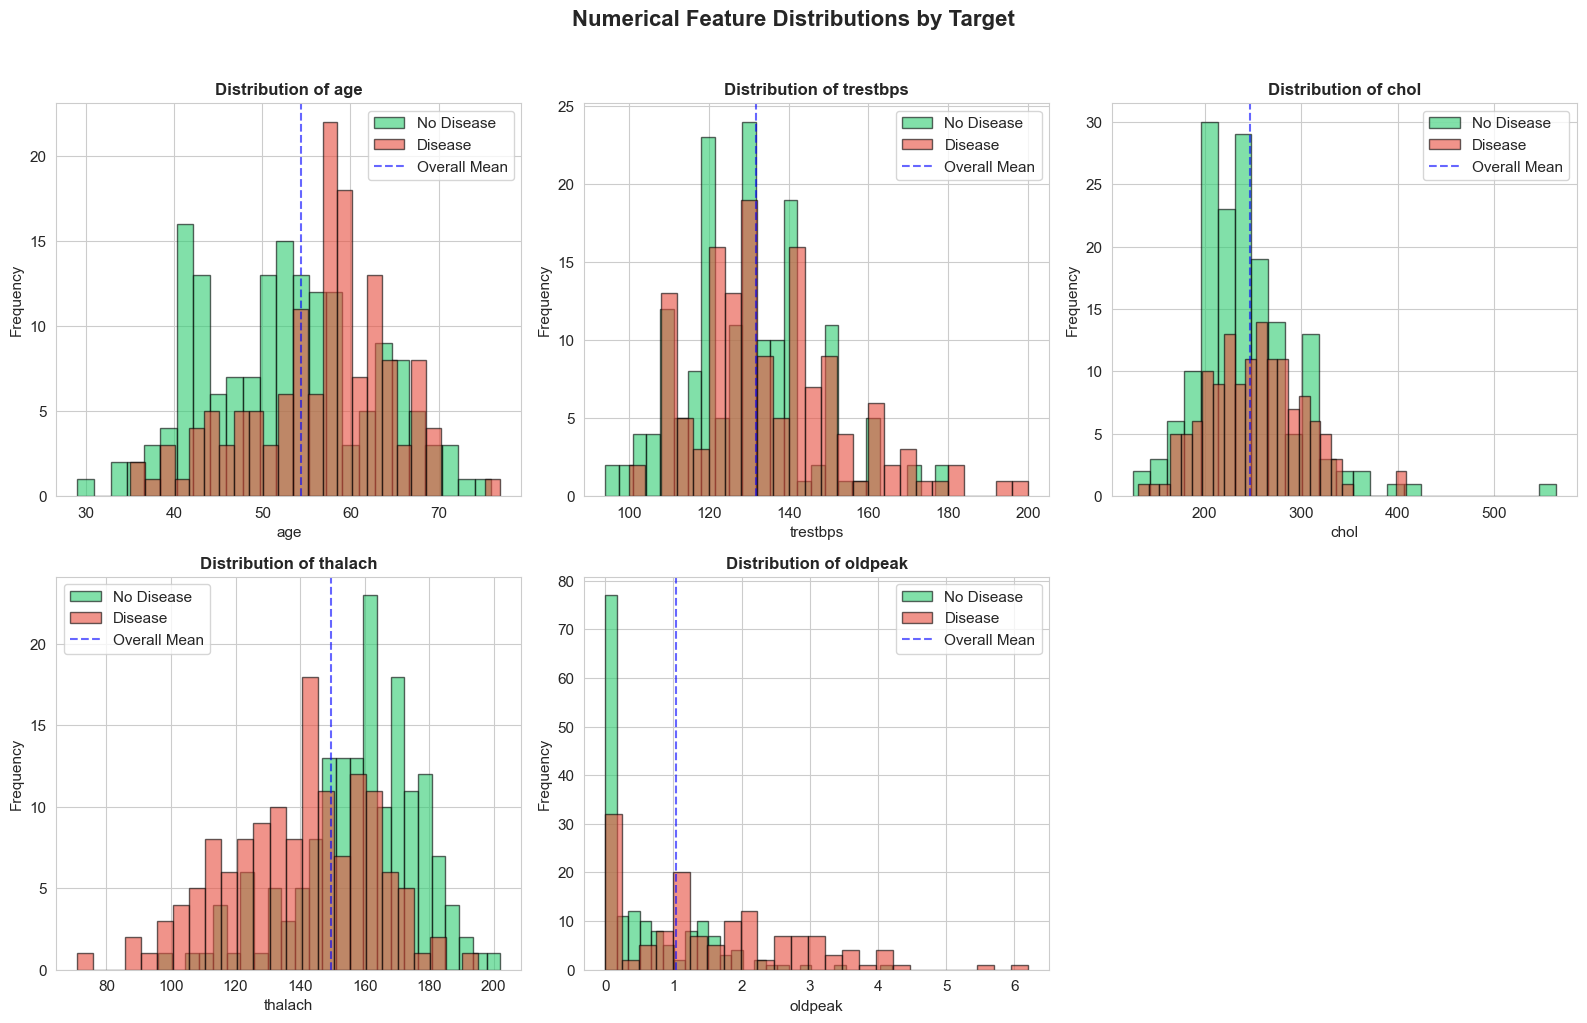

In [14]:
# Histograms with target overlay
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(
        df[df['target'] == 0][col].dropna(),
        bins=25, alpha=0.6, label='No Disease',
        color=PALETTE[0], edgecolor='black'
    )
    axes[i].hist(
        df[df['target'] == 1][col].dropna(),
        bins=25, alpha=0.6, label='Disease',
        color=PALETTE[1], edgecolor='black'
    )
    axes[i].axvline(df[col].mean(), color='blue', linestyle='--', alpha=0.6, label='Overall Mean')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

axes[-1].axis('off')  # Turn off the last empty subplot

plt.suptitle('Numerical Feature Distributions by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/histograms.png', dpi=100, bbox_inches='tight')
plt.show()

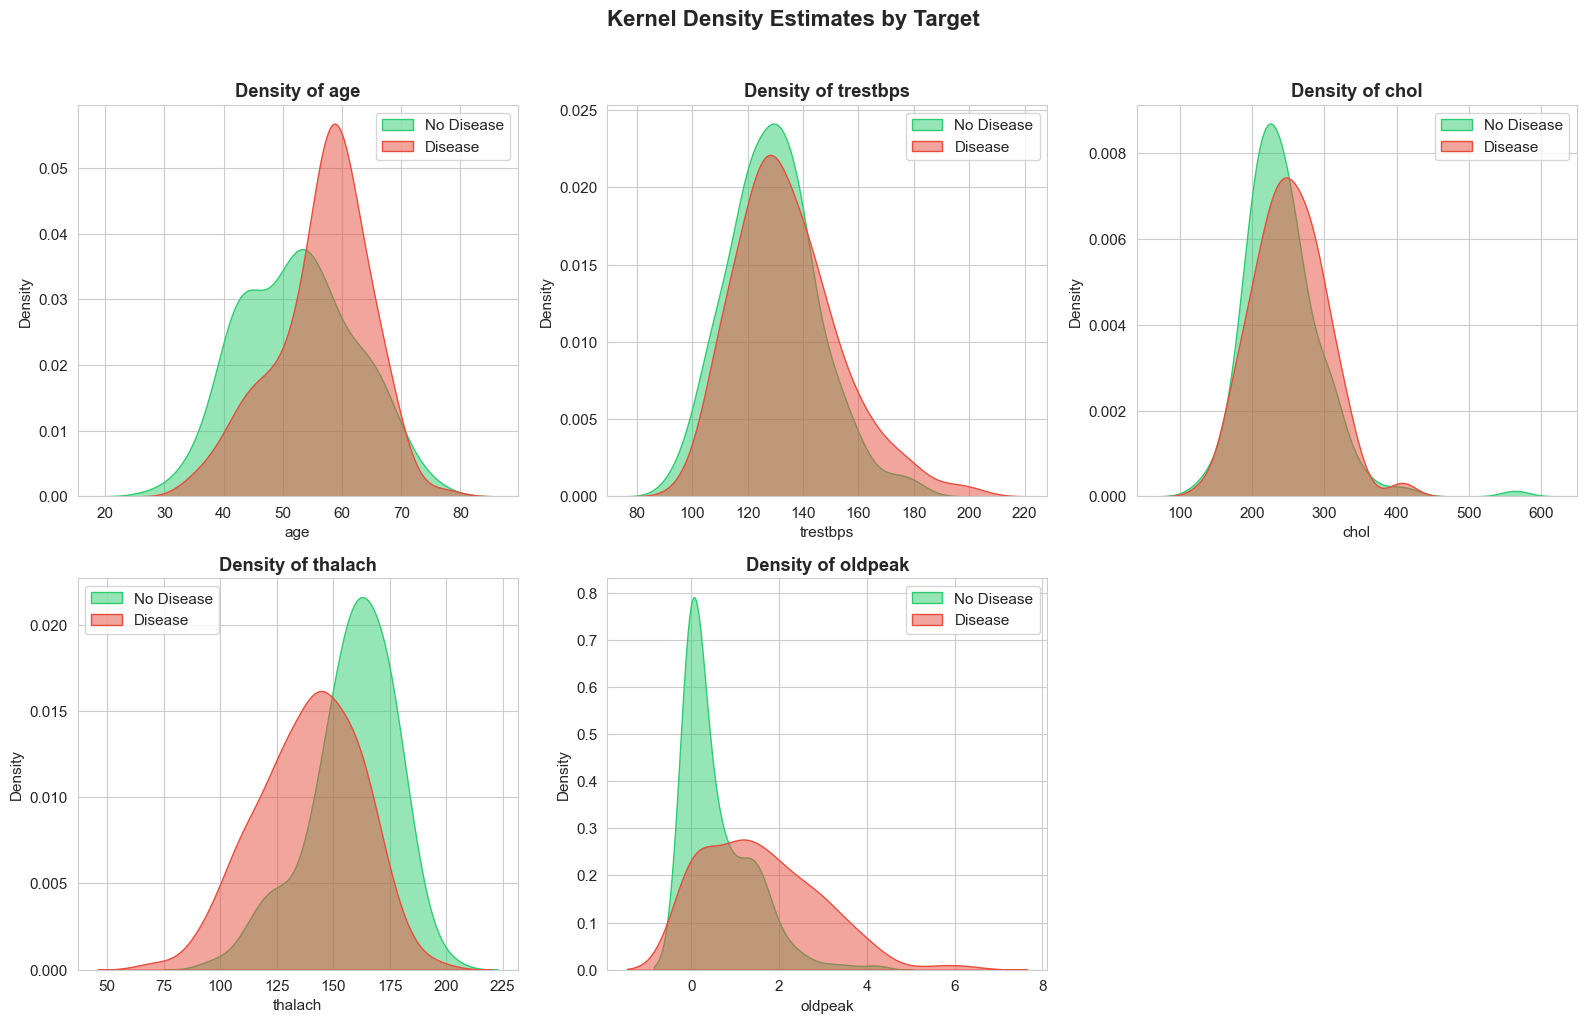

In [15]:
# Density plots (KDE) for numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.kdeplot(data=df[df['target'] == 0], x=col, ax=axes[i], color=PALETTE[0], label='No Disease', fill=True, alpha=0.5)
    sns.kdeplot(data=df[df['target'] == 1], x=col, ax=axes[i], color=PALETTE[1], label='Disease', fill=True, alpha=0.5)
    axes[i].set_title(f'Density of {col}', fontweight='bold')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Kernel Density Estimates by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/density_plots.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Correlation Analysis

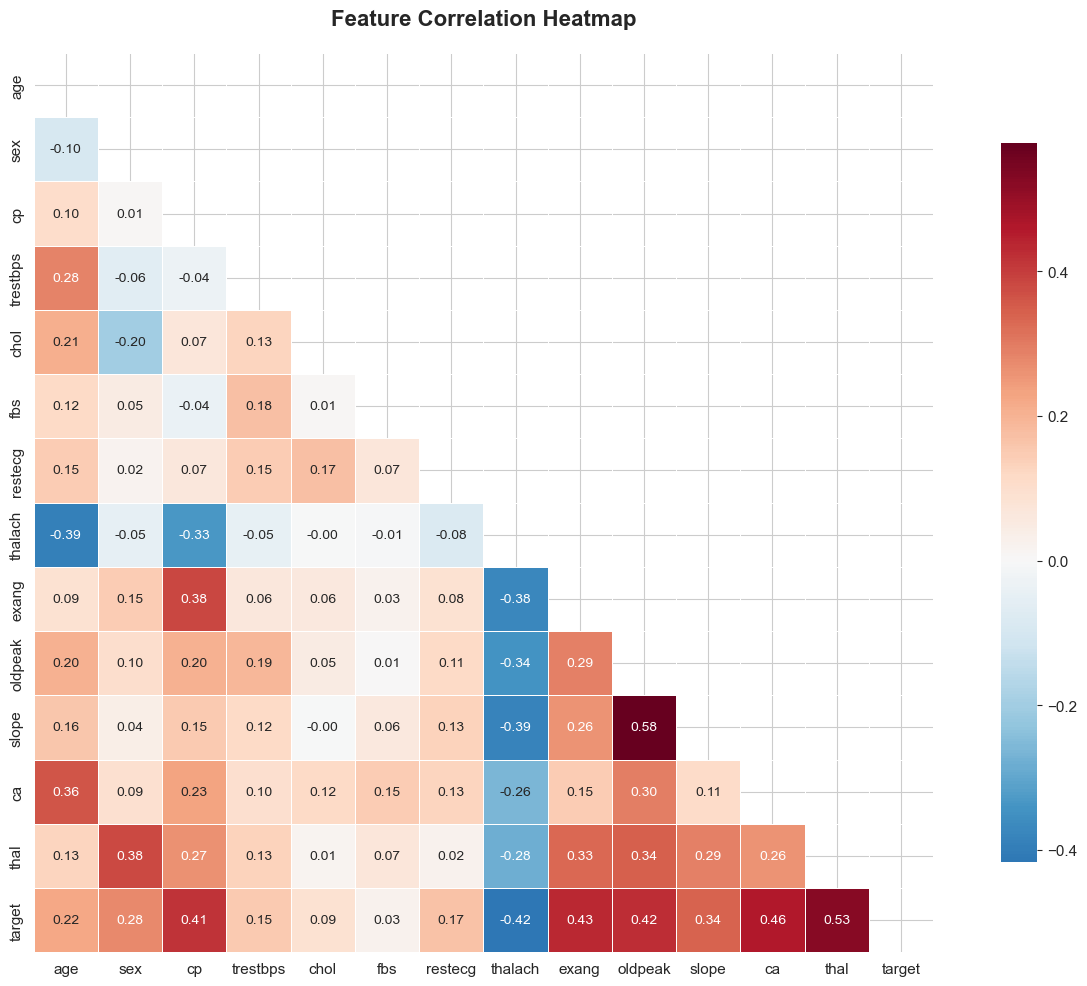

In [16]:
# Compute correlation matrix
corr = df.corr()

# Correlation heatmap with mask (upper triangle)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 10}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

🎯 Feature Correlation with Target (Absolute Value):
thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
thalach     0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target, dtype: float64


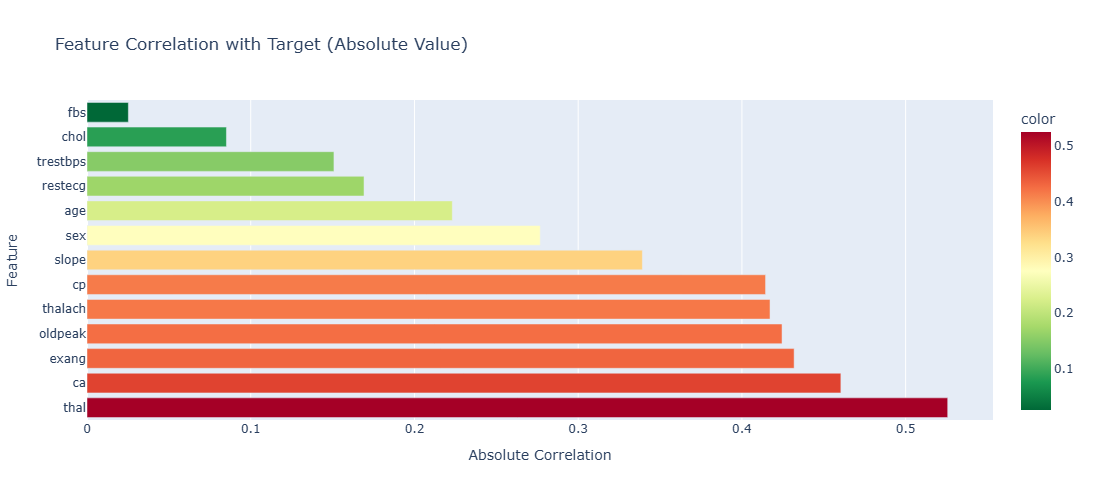

In [17]:
# Top features correlated with target
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print('🎯 Feature Correlation with Target (Absolute Value):')
print(target_corr.round(3))

# Visualize top correlations
fig = px.bar(
    x=target_corr.values, y=target_corr.index,
    orientation='h',
    title='Feature Correlation with Target (Absolute Value)',
    labels={'x': 'Absolute Correlation', 'y': 'Feature'},
    color=target_corr.values,
    color_continuous_scale='RdYlGn_r'
)
fig.update_layout(height=500, showlegend=False)
fig.show()

## 8. Categorical Feature Analysis

In [18]:
# Define categorical features
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print(f'📊 Categorical features: {cat_features}')
print('\nValue counts for each categorical feature:')
for col in cat_features:
    print(f'\n{col}:')
    print(df[col].value_counts().sort_index())

📊 Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Value counts for each categorical feature:

sex:
sex
0.0     97
1.0    206
Name: count, dtype: int64

cp:
cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64

fbs:
fbs
0.0    258
1.0     45
Name: count, dtype: int64

restecg:
restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

exang:
exang
0.0    204
1.0     99
Name: count, dtype: int64

slope:
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

ca:
ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

thal:
thal
3.0    166
6.0     18
7.0    117
Name: count, dtype: int64


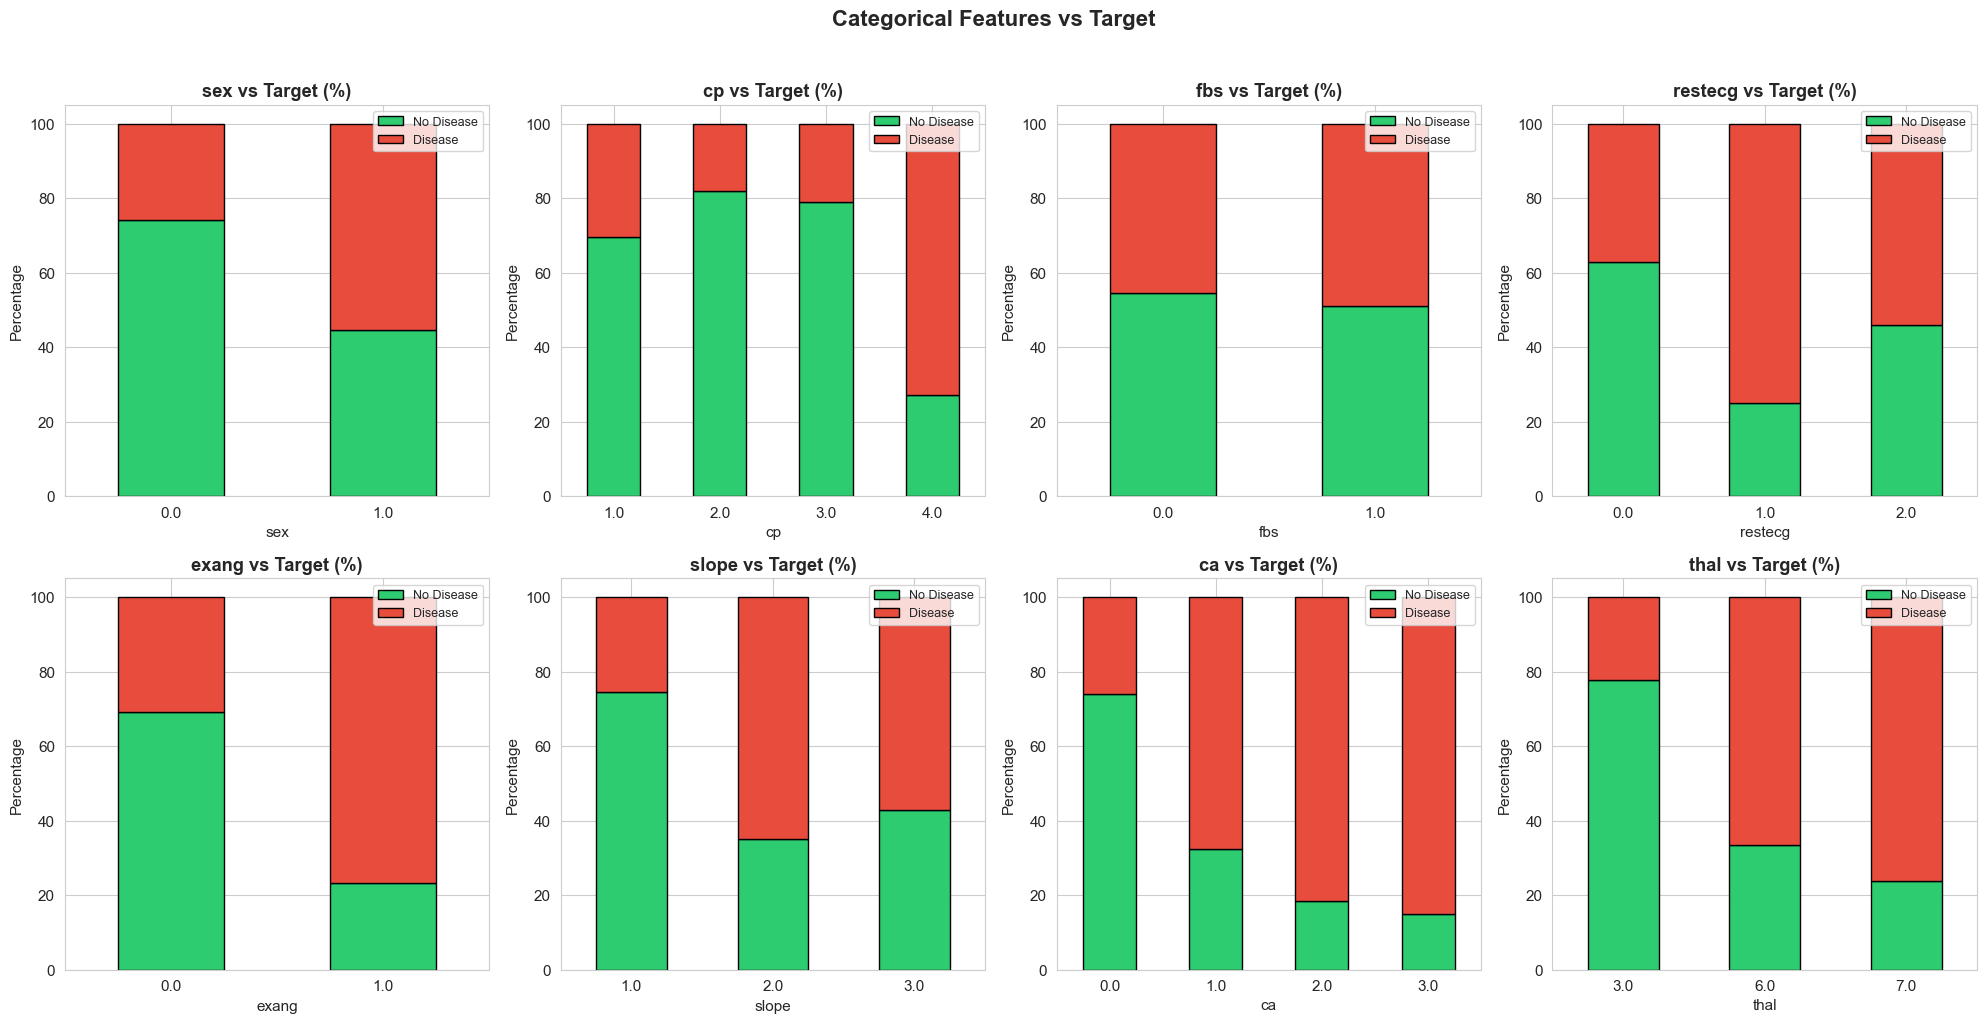

In [19]:
# Categorical vs Target analysis (stacked bar charts with percentages)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=PALETTE, stacked=True, edgecolor='black')
    axes[i].set_title(f'{col} vs Target (%)', fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel(col)
    axes[i].legend(['No Disease', 'Disease'], loc='upper right', fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/categorical_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

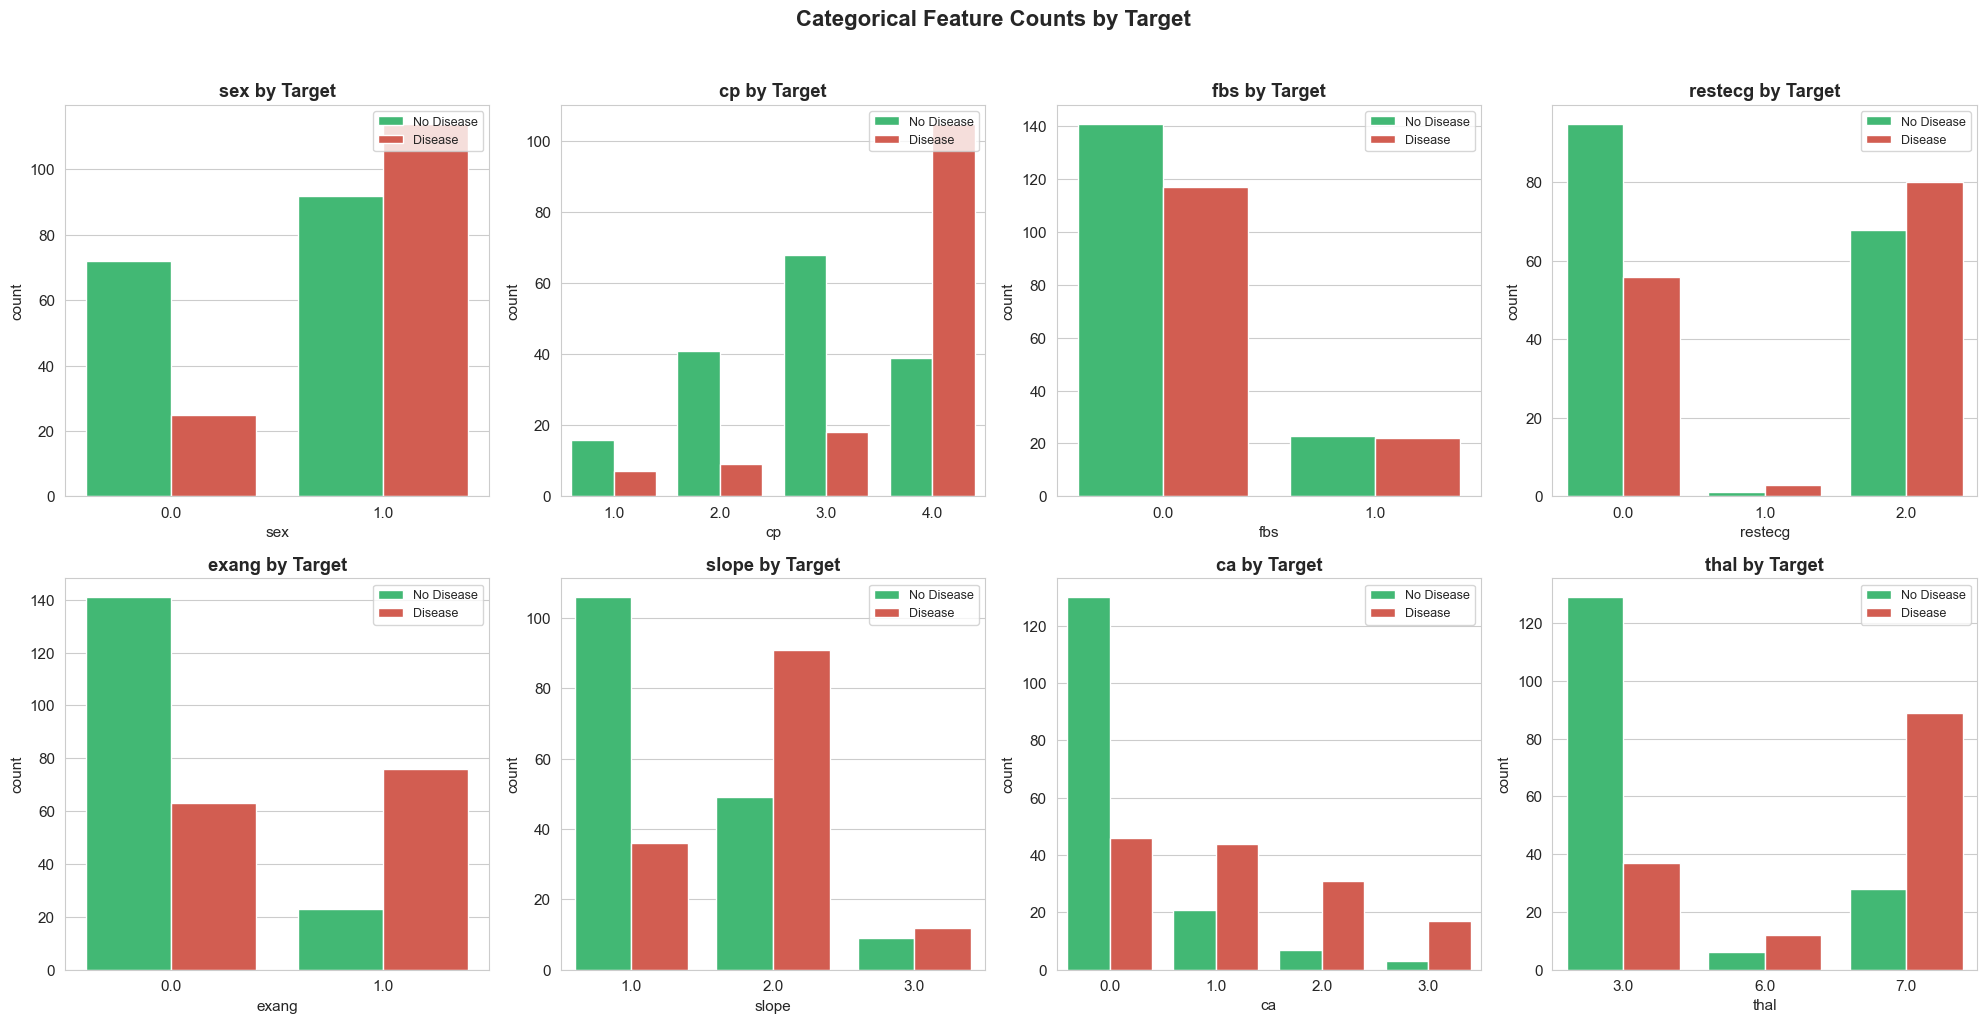

In [20]:
# Countplots for categorical features grouped by target
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i], palette=PALETTE)
    axes[i].set_title(f'{col} by Target', fontweight='bold')
    axes[i].legend(['No Disease', 'Disease'], loc='upper right', fontsize=9)

plt.suptitle('Categorical Feature Counts by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/categorical_counts.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Outlier Detection (Box Plots)

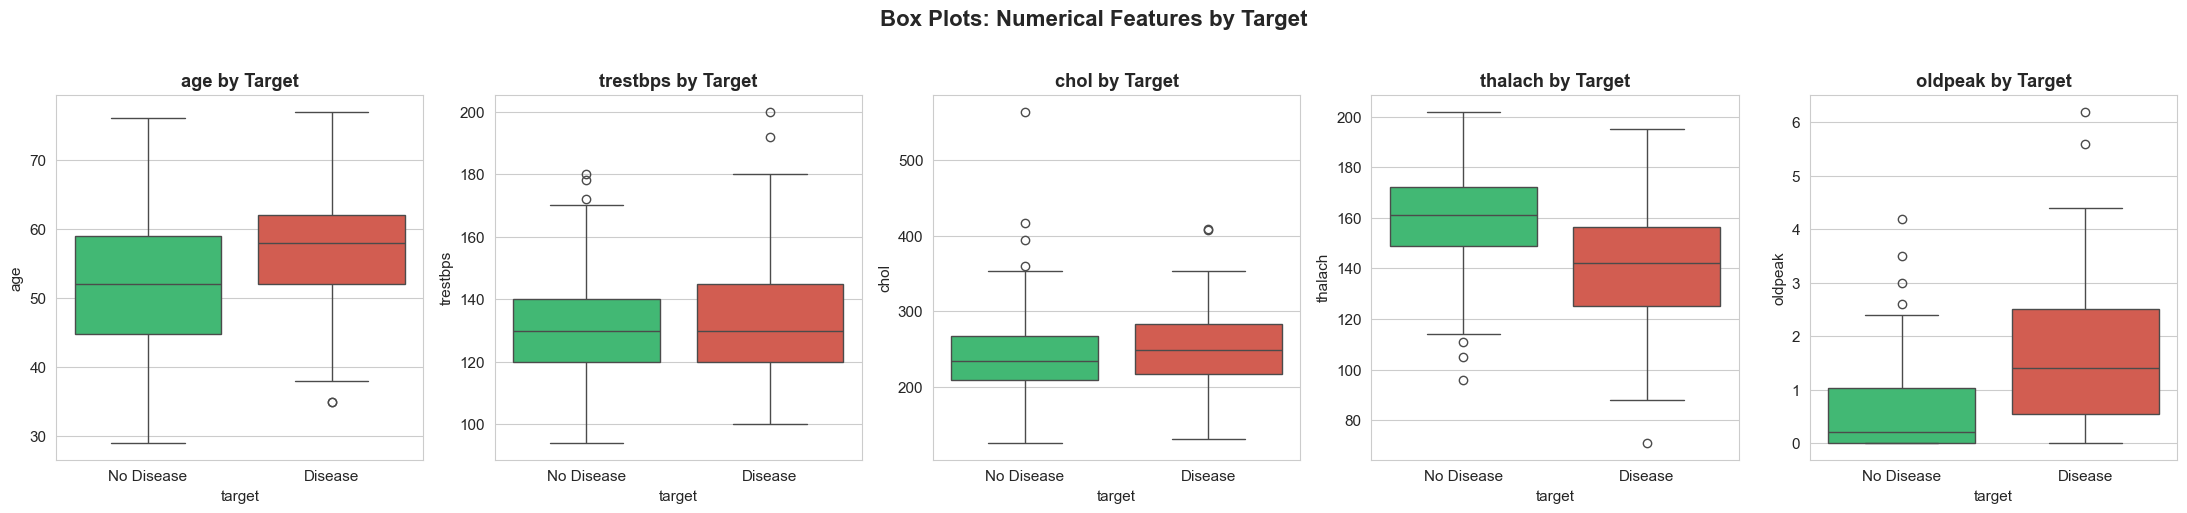

In [21]:
# Box plots for numerical features by target
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(num_features):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette=PALETTE)
    axes[i].set_title(f'{col} by Target', fontweight='bold')
    axes[i].set_xticklabels(['No Disease', 'Disease'])

plt.suptitle('Box Plots: Numerical Features by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

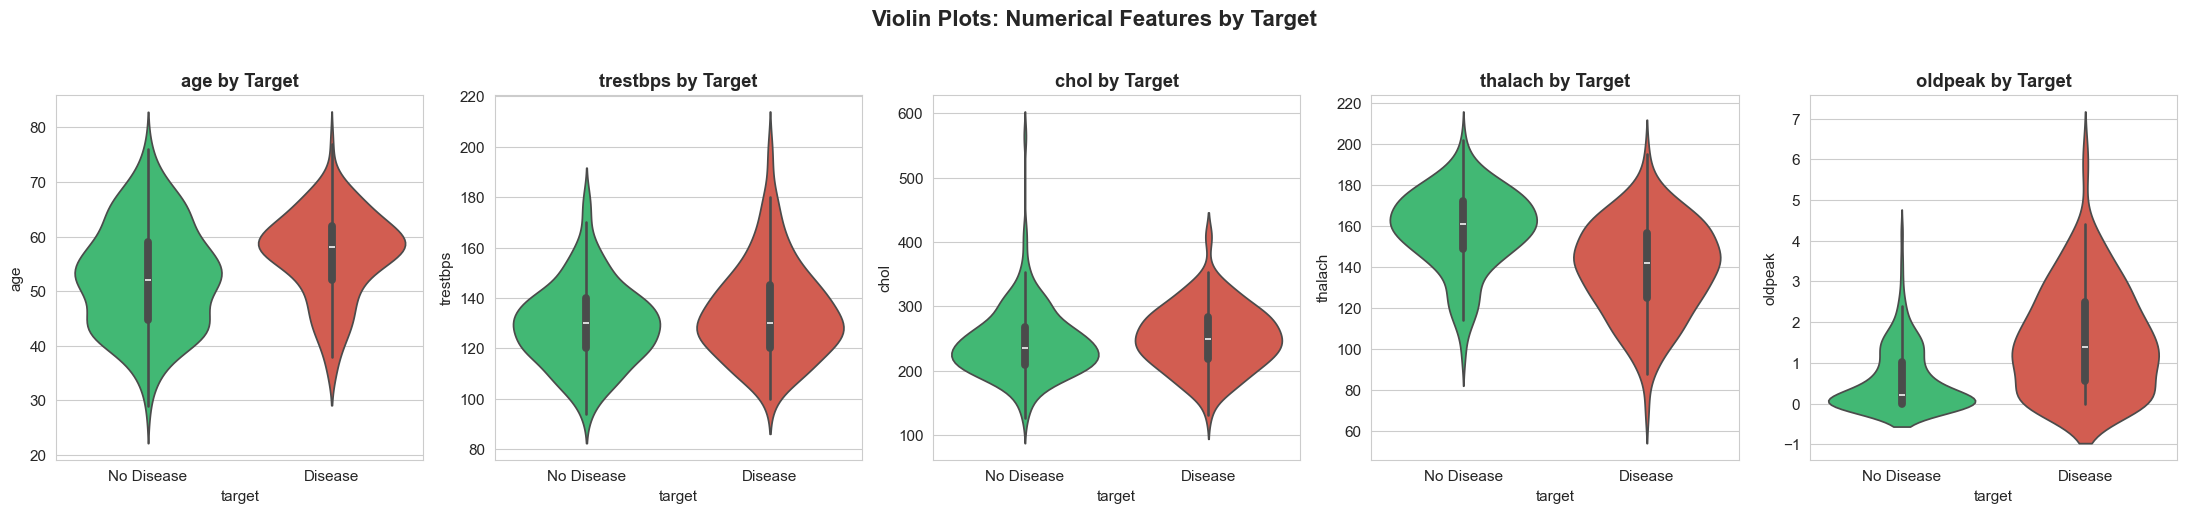

In [22]:
# Violin plots for a deeper distribution view
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(num_features):
    sns.violinplot(x='target', y=col, data=df, ax=axes[i], palette=PALETTE)
    axes[i].set_title(f'{col} by Target', fontweight='bold')
    axes[i].set_xticklabels(['No Disease', 'Disease'])

plt.suptitle('Violin Plots: Numerical Features by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/violinplots.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
# IQR-based outlier detection
print('🔍 IQR-based Outlier Detection for Numerical Features:')
print('=' * 60)

outlier_summary = {}
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Outlier Count': len(outliers),
        'Outlier %': round((len(outliers) / len(df)) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

🔍 IQR-based Outlier Detection for Numerical Features:
          Outlier Count  Outlier %
age                 0.0       0.00
trestbps            9.0       2.97
chol                5.0       1.65
thalach             1.0       0.33
oldpeak             5.0       1.65


## 10. Interactive Visualizations (Plotly)

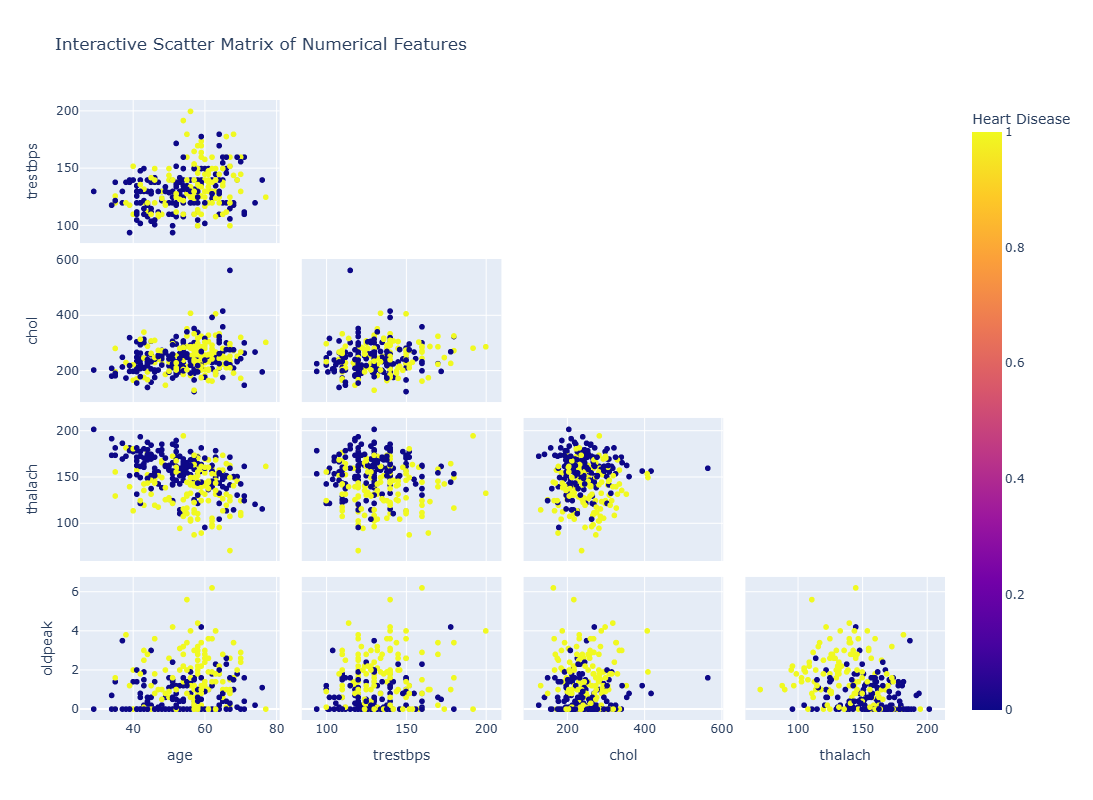

In [24]:
# Interactive scatter matrix
fig = px.scatter_matrix(
    df,
    dimensions=['age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
    color='target',
    color_discrete_map={0: PALETTE[0], 1: PALETTE[1]},
    title='Interactive Scatter Matrix of Numerical Features',
    labels={'target': 'Heart Disease'}
)
fig.update_layout(height=800, showlegend=True)
fig.update_traces(diagonal_visible=False, showupperhalf=False)
fig.show()

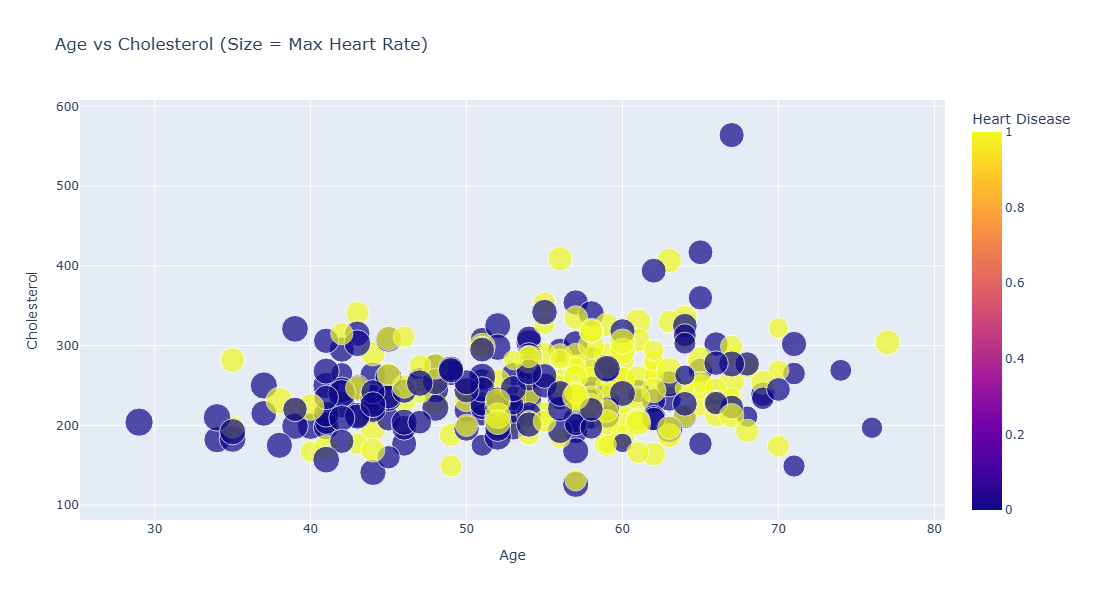

In [25]:
# Age vs Cholesterol interactive plot
fig = px.scatter(
    df, x='age', y='chol',
    color='target', size='thalach',
    hover_data=['sex', 'cp', 'trestbps', 'oldpeak'],
    color_discrete_map={0: PALETTE[0], 1: PALETTE[1]},
    title='Age vs Cholesterol (Size = Max Heart Rate)',
    labels={'target': 'Heart Disease', 'chol': 'Cholesterol', 'age': 'Age'}
)
fig.update_layout(height=600)
fig.show()

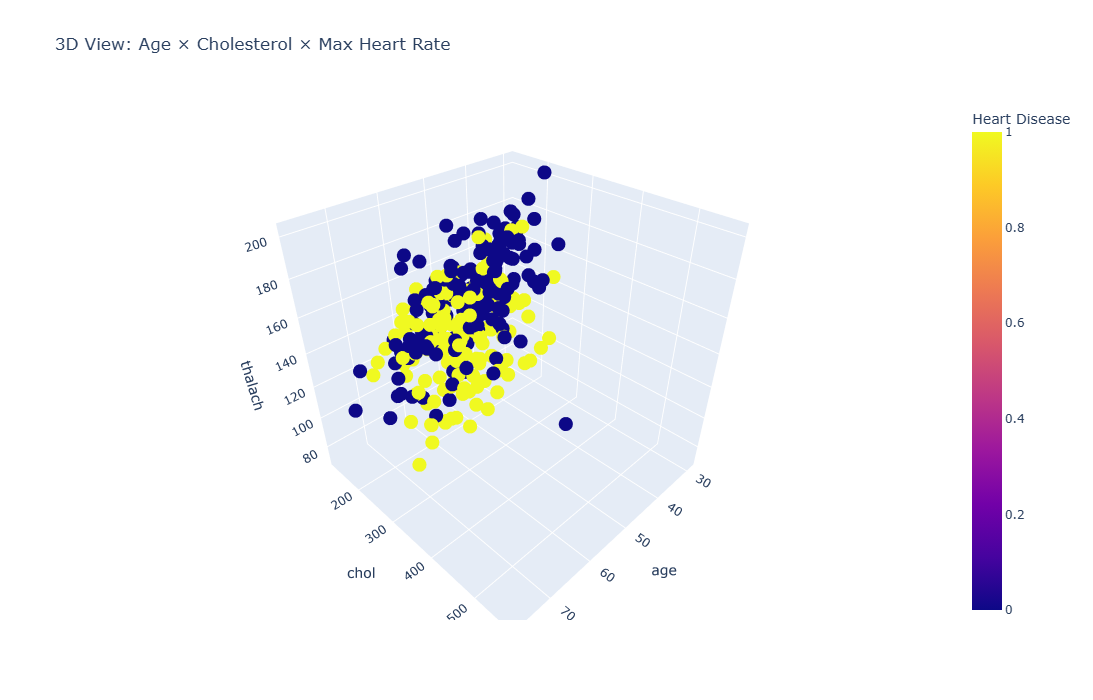

In [26]:
# 3D scatter: Age, Cholesterol, Max HR
fig = px.scatter_3d(
    df, x='age', y='chol', z='thalach',
    color='target',
    color_discrete_map={0: PALETTE[0], 1: PALETTE[1]},
    title='3D View: Age × Cholesterol × Max Heart Rate',
    labels={'target': 'Heart Disease'}
)
fig.update_layout(height=700)
fig.show()

In [28]:
print(df[['sex','cp','target']].nunique())

print(df['cp'].value_counts(dropna=False))

print(df['sex'].value_counts(dropna=False))

print(df['target'].value_counts(dropna=False))

sex       2
cp        4
target    2
dtype: int64
cp
4.0    144
3.0     86
2.0     50
1.0     23
Name: count, dtype: int64
sex
1.0    206
0.0     97
Name: count, dtype: int64
target
0    164
1    139
Name: count, dtype: int64


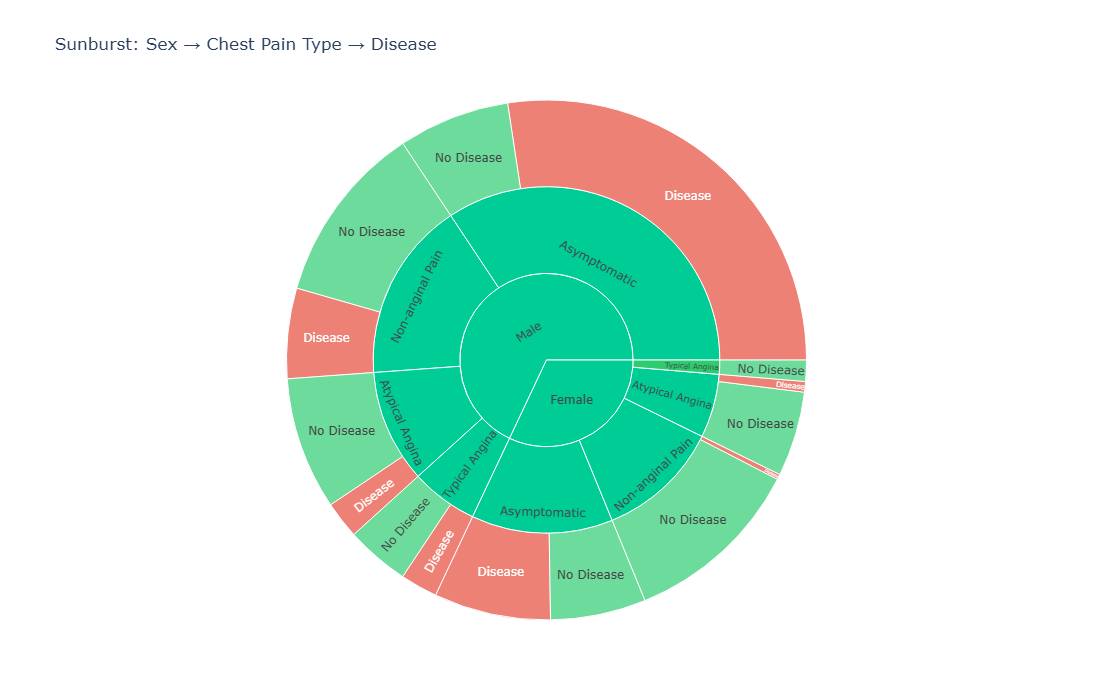

In [30]:
import plotly.express as px
import pandas as pd

# Label mappings for your dataset
sex_map = {
    0: "Female",
    1: "Male"
}

cp_map = {
    1: "Typical Angina",
    2: "Atypical Angina",
    3: "Non-anginal Pain",
    4: "Asymptomatic"
}

target_map = {
    0: "No Disease",
    1: "Disease"
}

# Create a clean copy
sun = df.copy()

sun["sex"] = sun["sex"].astype(int).map(sex_map)
sun["cp"] = sun["cp"].astype(int).map(cp_map)
sun["target"] = sun["target"].astype(int).map(target_map)

# Aggregate counts
agg = (
    sun.groupby(["sex", "cp", "target"])
       .size()
       .reset_index(name="count")
)

fig = px.sunburst(
    agg,
    path=["sex", "cp", "target"],
    values="count",
    color="target",
    color_discrete_map={
        "Disease": PALETTE[1],
        "No Disease": PALETTE[0]
    },
    title="Sunburst: Sex → Chest Pain Type → Disease"
)

fig.update_layout(height=700)
fig.show()

## 11. Age Group Analysis

In [31]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 70, 120],
    labels=['<40', '40-55', '55-70', '>70']
)

# Disease rate by age group
age_disease = df.groupby('age_group')['target'].agg(['count', 'sum'])
age_disease['disease_rate_%'] = (age_disease['sum'] / age_disease['count'] * 100).round(2)
print('🩺 Disease Rate by Age Group:')
print(age_disease)

🩺 Disease Rate by Age Group:
           count  sum  disease_rate_%
age_group                            
<40           18    6           33.33
40-55        133   43           32.33
55-70        146   89           60.96
>70            6    1           16.67


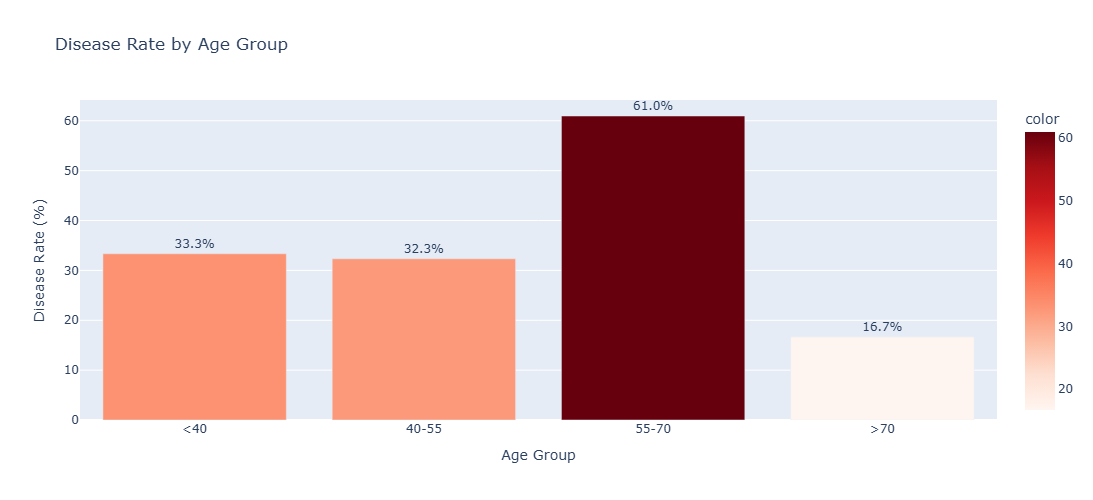

In [32]:
# Visualize disease rate by age group
fig = px.bar(
    x=age_disease.index.astype(str),
    y=age_disease['disease_rate_%'],
    title='Disease Rate by Age Group',
    labels={'x': 'Age Group', 'y': 'Disease Rate (%)'},
    color=age_disease['disease_rate_%'],
    color_continuous_scale='Reds',
    text=age_disease['disease_rate_%']
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=500, showlegend=False)
fig.show()

# Remove the age_group column (was just for analysis)
df.drop(columns='age_group', inplace=True)

## 12. Feature Relationships

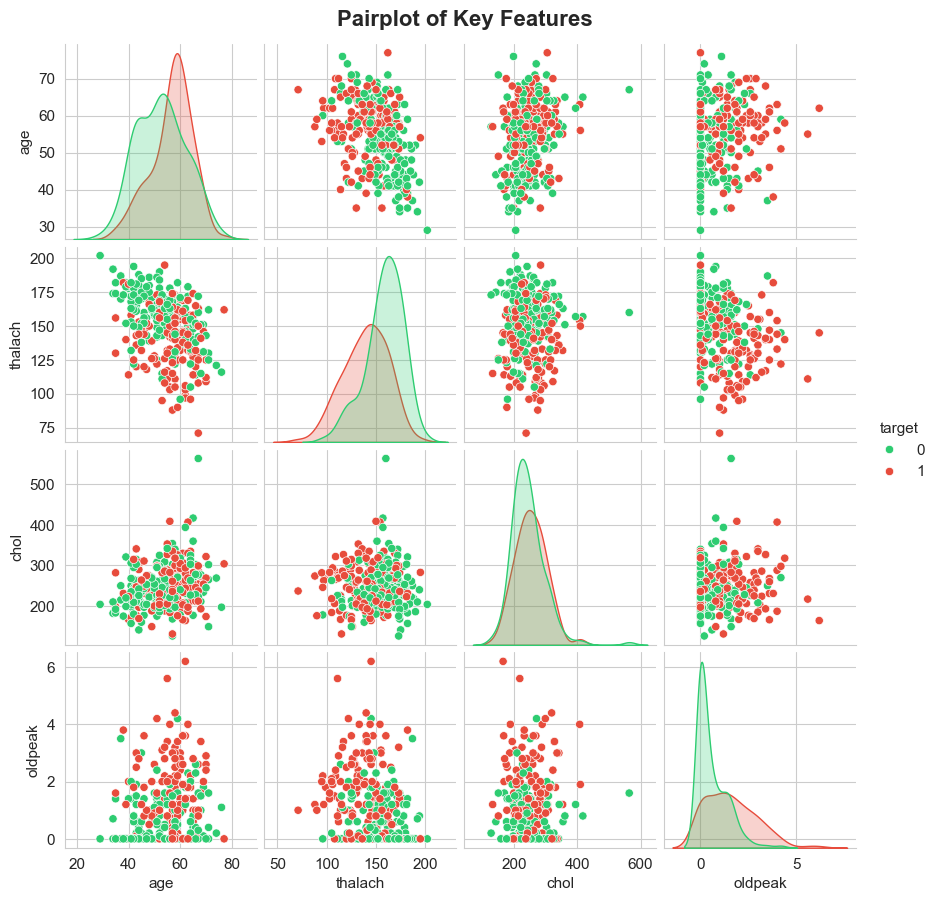

In [33]:
# Pairplot of key features
key_features = ['age', 'thalach', 'chol', 'oldpeak', 'target']
sns.pairplot(df[key_features], hue='target', palette=PALETTE, diag_kind='kde', height=2.2)
plt.suptitle('Pairplot of Key Features', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../screenshots/mlflow/pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

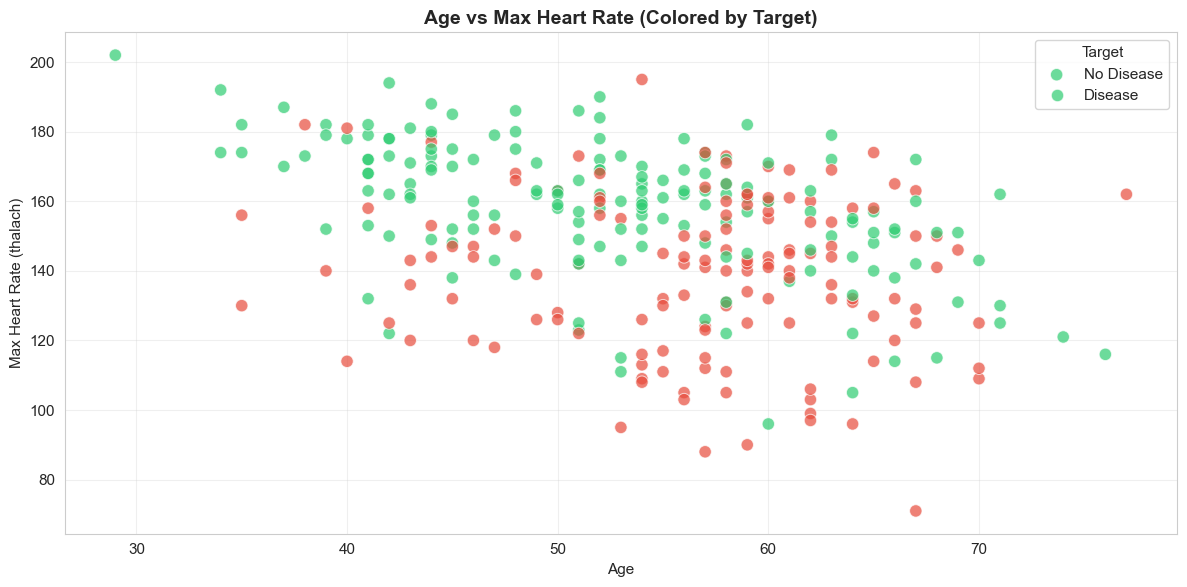

In [34]:
# Age vs Max Heart Rate (thalach) by target
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette=PALETTE, s=80, alpha=0.7)
plt.title('Age vs Max Heart Rate (Colored by Target)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (thalach)')
plt.legend(['No Disease', 'Disease'], title='Target')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/age_vs_thalach.png', dpi=100, bbox_inches='tight')
plt.show()

## 13. Summary Statistics by Target

In [35]:
# Compare means of numerical features between target classes
print('📊 Mean values of numerical features by target:')
print(df.groupby('target')[num_features].mean().round(2))

print('\n📊 Median values of numerical features by target:')
print(df.groupby('target')[num_features].median().round(2))

📊 Mean values of numerical features by target:
          age  trestbps    chol  thalach  oldpeak
target                                           
0       52.59    129.25  242.64   158.38     0.59
1       56.63    134.57  251.47   139.26     1.57

📊 Median values of numerical features by target:
         age  trestbps   chol  thalach  oldpeak
target                                         
0       52.0     130.0  234.5    161.0      0.2
1       58.0     130.0  249.0    142.0      1.4


In [36]:
# Percentage distribution of categorical features by target
print('📊 Percentage distribution of categorical features by target:')
print('=' * 60)
for col in cat_features:
    print(f'\n{col.upper()}:')
    ct = pd.crosstab(df[col], df['target'], normalize='columns') * 100
    print(ct.round(2))

📊 Percentage distribution of categorical features by target:

SEX:
target     0      1
sex                
0.0     43.9  17.99
1.0     56.1  82.01

CP:
target      0      1
cp                  
1.0      9.76   5.04
2.0     25.00   6.47
3.0     41.46  12.95
4.0     23.78  75.54

FBS:
target      0      1
fbs                 
0.0     85.98  84.17
1.0     14.02  15.83

RESTECG:
target       0      1
restecg              
0.0      57.93  40.29
1.0       0.61   2.16
2.0      41.46  57.55

EXANG:
target      0      1
exang               
0.0     85.98  45.32
1.0     14.02  54.68

SLOPE:
target      0      1
slope               
1.0     64.63  25.90
2.0     29.88  65.47
3.0      5.49   8.63

CA:
target      0      1
ca                  
0.0     80.75  33.33
1.0     13.04  31.88
2.0      4.35  22.46
3.0      1.86  12.32

THAL:
target      0      1
thal                
3.0     79.14  26.81
6.0      3.68   8.70
7.0     17.18  64.49


## 🔑 Key Insights from EDA

### 📊 Dataset Overview
1. **Size:** 303 patient records with 14 features (13 predictors + 1 target)
2. **Class Balance:** Dataset is well-balanced (~54% No Disease, ~46% Disease) - **no oversampling needed**
3. **Missing Values:** Only `ca` and `thal` have minor missing values (<3%) - handled via mode imputation

### 🎯 Key Predictors (Top 5 by correlation with target)
1. **thalach** (Max Heart Rate) - **Strong negative correlation** → Lower thalach = Higher disease risk
2. **oldpeak** (ST Depression) - **Strong positive correlation** → Higher oldpeak = Higher risk
3. **cp** (Chest Pain Type) - Type 0 (typical angina) strongly indicates disease
4. **exang** (Exercise Angina) - Positive exang strongly predicts disease
5. **ca** (Major Vessels) - More affected vessels correlate with disease

### 👥 Demographic Insights
- **Age:** Disease patients tend to be older (mean ~56 vs ~52)
- **Sex:** Males (sex=1) show higher disease prevalence in this cohort
- **Age Groups:** Disease rate increases significantly after age 55

### 🩺 Clinical Insights
- **Max Heart Rate:** Disease patients achieve lower max HR during exercise
- **Cholesterol:** Mild positive correlation with disease
- **Blood Pressure:** Slightly higher in disease patients
- **ST Depression (oldpeak):** Strong predictor - values > 1.0 signal higher risk

### 🛠️ Feature Engineering Strategy
Based on these insights, we will create:
1. **Age groups:** Bin into [<40, 40-55, 55-70, >70] for non-linear age effects
2. **HR-Age ratio:** `thalach / age` captures cardiovascular fitness
3. **Age × Cholesterol interaction:** Combined cardiovascular risk
4. **BP-Cholesterol ratio:** Metabolic health indicator
5. **Cholesterol categories:** Normal (<200), Borderline (200-240), High (>240)

### 🚀 Next Steps
1. Apply feature engineering in `src/data_preprocessing.py`
2. Train multiple models with hyperparameter tuning (see `02_Model_Training.ipynb`)
3. Track experiments with MLflow
4. Deploy best model via FastAPI

## 📁 Generated Artifacts

The following plots have been saved to `../screenshots/mlflow/`:
- `missing_heatmap.png`
- `class_distribution.png`
- `histograms.png`
- `density_plots.png`
- `correlation_heatmap.png`
- `categorical_analysis.png`
- `categorical_counts.png`
- `boxplots.png`
- `violinplots.png`
- `pairplot.png`
- `age_vs_thalach.png`

---